In [1]:
from Functions import utils as u

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Obtain Data

In [2]:
data = u.extract_data(UMP_threshold=-3.0)

display(data)

#features_and_label = ['Teff', 'NUVDered','logg','bp_rp_dered','UMP_flag']
features_and_label = ['Teff','logg', 'bp_rp_dered', 'colorColorY','UMP_flag']
selected_data = data[features_and_label].copy()

#remove all rows where logg is Nan
#selected_data = selected_data.dropna(subset=['logg'])

print(f"Num of UMPs: {len(selected_data[selected_data['UMP_flag']==1])}, Num of non-UMPs:{len(selected_data[selected_data['UMP_flag']!=1])}")

print(f'EMP fraction = {len(selected_data[selected_data['UMP_flag']==1])/len(selected_data)}')


,Survey,FeH,NUVDered,bp_rp_dered,Teff,logg,colorColorY,UMP_flag
0,Bonifacio,-2.83,20.194627,1.003094,6303.000000,4.2500,-1.016775,0
1,Cayrel,-2.09,13.763638,0.878489,5250.000000,2.0000,-1.077013,0
2,Cayrel,-3.06,13.687658,1.019055,19883.960938,3.8566,-1.862718,1
3,Cayrel,-3.71,17.854393,0.883936,5250.000000,3.0000,-1.778273,1
4,Cayrel,-3.35,19.073609,1.022003,5456.290527,2.7236,-1.514804,1
...,...,...,...,...,...,...,...,...
587,Yong,-2.60,18.570030,0.582178,6507.000000,4.2900,-1.297989,0
588,Yong,-2.65,17.412597,0.570395,6624.000000,4.1100,-1.041163,0
589,Yong,-2.60,18.019629,0.580172,6479.000000,4.3100,-1.252573,0
590,Yong,-2.68,18.129256,0.664409,6196.000000,3.7700,-1.605187,0


Num of UMPs: 195, Num of non-UMPs:397
EMP fraction = 0.3293918918918919


# Scale and Split, Select if you wish to include SMOTE

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from imblearn.under_sampling import EditedNearestNeighbours



def scale_and_split(data, target_column, test_size=0.2, random_state=42, use_smote = False):
    """
    Splits the dataset into training and validation sets, and scales the features.

    Parameters:
    - data: pd.DataFrame
    - target_column: str, name of the target column
    - test_size: float, proportion of validation set
    - random_state: int, for reproducibility

    Returns:
    - X_train_scaled, X_val_scaled, y_train, y_val, scaler
    """
    # Separate features and target
    X = data.drop(columns=[target_column]).copy()
    y = data[target_column].copy()

    # Split into train and validation
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    #Resample with smote if True
    if use_smote:
        smote = SMOTEENN(
            #sampling_strategy=0.7,
            random_state=random_state)
        X_train, y_train = smote.fit_resample(X_train, y_train)

    #Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    return X_train_scaled, X_val_scaled, y_train, y_val, scaler

x_train, x_val, y_train, y_val,scaler= scale_and_split(selected_data, 'UMP_flag', use_smote=False)



# Logistic Regression

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.metrics import (
    precision_recall_curve, 
    precision_score, recall_score, confusion_matrix, 
    ConfusionMatrixDisplay
)
from imblearn.combine import SMOTEENN

from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import EditedNearestNeighbours





def UMP_predictor_model(X_train, y_train, X_valid, y_valid, target_precision=0.90):
    """
    Logistic Regression optimized for high precision using SMOTEENN + threshold tuning.
    """

    # -------------------------
    # 3. Model + Halving Grid Search
    # -------------------------
    model = LogisticRegression(
        #class_weight={0:1,1:3},
        class_weight='balanced',
        solver='lbfgs',
        max_iter=10000
    )

    param_grid = {
        'C': np.logspace(-1, 2, 40), 
        #'class_weight':[{0:1,1:50},{0:1,1:500},{0:1,1:10},{0:1,1:25},{0:1,1:100}]
        }

    search = HalvingGridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring='precision',
        cv=5,
        factor=3,
        verbose=1
    )

    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    print(f"\nBest C: {search.best_params_['C']:.5f}")

    # -------------------------
    # 4. Validation Predictions
    # -------------------------
    y_probs = best_model.predict_proba(X_valid)[:, 1]

    # Compute precision-recall pairs
    precisions, recalls, thresholds = precision_recall_curve(y_valid, y_probs)

    # Select threshold: highest recall among thresholds meeting target precision

    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
    best_index = np.argmax(f1_scores)
    best_threshold = thresholds[best_index] if best_index < len(thresholds) else 0.5

    print(f"Selected Threshold = {best_threshold:.3f}")

    y_pred = (y_probs >= best_threshold).astype(int)

    # -------------------------
    # 5. Evaluation Metrics
    # -------------------------
    print(f"Precision: {precision_score(y_valid, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_valid, y_pred):.4f}")

    cm = confusion_matrix(y_valid, y_pred)
    plt.figure(figsize=(5, 4))
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
    plt.title(f"Confusion Matrix (threshold={best_threshold:.2f})")
    plt.show()

    # -------------------------
    # 6. Precision vs C Plot
    # -------------------------
    mean_test_scores = search.cv_results_['mean_test_score']
    C_values = search.cv_results_['param_C'].data.astype(float)

    plt.figure(figsize=(7, 5))
    plt.semilogx(C_values, mean_test_scores, marker='o')
    plt.xlabel("Regularization Strength C (log scale)")
    plt.ylabel("CV Precision")
    plt.title("Precision vs Regularization Strength (C)")
    plt.grid(True)
    plt.show()

    # -------------------------
    # 7. Precision-Recall Curve
    # -------------------------
    plt.figure(figsize=(7, 5))
    plt.plot(recalls, precisions)
    
    plt.scatter(recalls[best_index], precisions[best_index], color='red', s=80,
                label=f"Best Threshold = {best_threshold:.3f}")
    
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.ylim(0,1)
    plt.title("Precision–Recall Curve")
    plt.grid(True)
    plt.show()

    return best_model, best_threshold


n_iterations: 3
n_required_iterations: 4
n_possible_iterations: 3
min_resources_: 20
max_resources_: 473
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 40
n_resources: 20
Fitting 5 folds for each of 40 candidates, totalling 200 fits


c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\fderi\.conda\envs\s

----------
iter: 1
n_candidates: 14
n_resources: 60
Fitting 5 folds for each of 14 candidates, totalling 70 fits
----------
iter: 2
n_candidates: 5
n_resources: 180
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best C: 34.55107
Selected Threshold = 0.390
Precision: 0.3491
Recall:    0.9487


<Figure size 500x400 with 0 Axes>

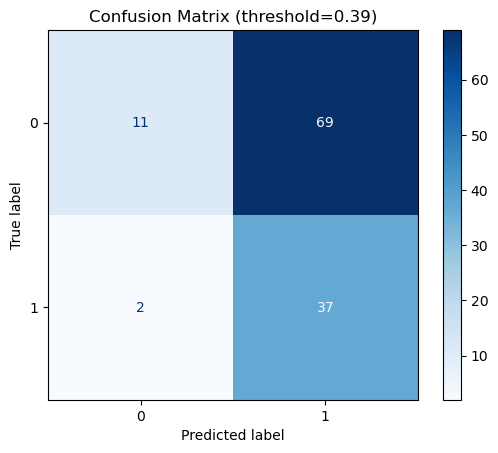

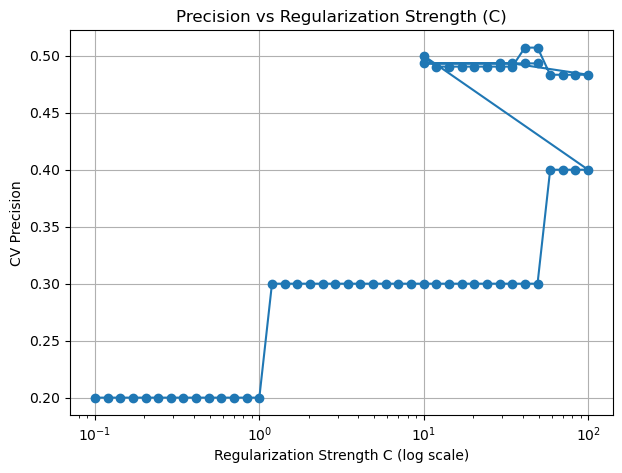

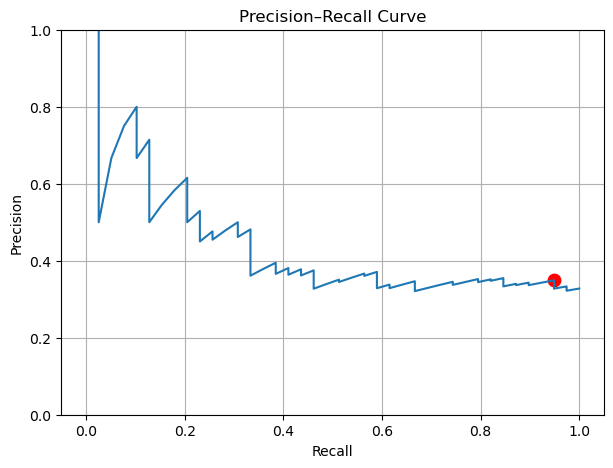

In [5]:
# Assuming you already have X_train_scaled, X_val_scaled, y_train, y_val
best_model,best_threshold = UMP_predictor_model(x_train, y_train, x_val, y_val,target_precision=0.60)


In [6]:
#Create parameter space plots

#groups = 

In [7]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# from sklearn.preprocessing import StandardScaler
# from sklearn.experimental import enable_halving_search_cv  # noqa
# from sklearn.model_selection import HalvingGridSearchCV
# from sklearn.metrics import (
#     precision_recall_curve,
#     precision_score, recall_score, confusion_matrix,
#     ConfusionMatrixDisplay
# )

# from imblearn.over_sampling import ADASYN
# from xgboost import XGBClassifier


# def UMP_predictor_model(X_train, y_train, X_valid, y_valid, target_precision=0.90):
#     """
#     High-precision classifier using ADASYN + XGBoost + threshold tuning.
#     """

#     # -------------------------
#     # 1. Oversample Hard Minority Regions with ADASYN
#     # -------------------------
#     adasyn = ADASYN(random_state=42, n_neighbors=5)
#     X_train_res, y_train_res = adasyn.fit_resample(X_train, y_train)

#     # -------------------------
#     # 2. Scale data AFTER resampling
#     # -------------------------
#     scaler = StandardScaler()
#     X_train_res = scaler.fit_transform(X_train_res)
#     X_valid_scaled = scaler.transform(X_valid)

#     # -------------------------
#     # 3. Model + Halving Grid Search
#     # -------------------------
#     # Class imbalance adjustment for XGBoost
#     scale_pos_weight = (y_train_res == 0).sum() / (y_train_res == 1).sum()

#     base_model = XGBClassifier(
#         scale_pos_weight=scale_pos_weight,
#         eval_metric="logloss",
#     )

#     param_grid = {
#         "max_depth": [2, 3, 4, 5],
#         "learning_rate": [0.01],
#         "n_estimators": [100, 200, 300],
#         "subsample": [0.7, 0.9, 1.0],
#         "colsample_bytree": [0.7, 1.0]
#     }

#     search = HalvingGridSearchCV(
#         estimator=base_model,
#         param_grid=param_grid,
#         scoring="precision",
#         cv=5,
#         factor=3,
#         verbose=1
#     )

#     search.fit(X_train_res, y_train_res)
#     best_model = search.best_estimator_

#     print("\nBest Hyperparameters Found:")
#     print(search.best_params_)

#     # -------------------------
#     # 4. Validation Probability Scores
#     # -------------------------
#     y_probs = best_model.predict_proba(X_valid_scaled)[:, 1]

#     precisions, recalls, thresholds = precision_recall_curve(y_valid, y_probs)

#     # Pick threshold: highest recall such that precision >= target_precision
#     idx = np.where(precisions >= target_precision)[0]
#     if len(idx) > 0:
#         i = idx[np.argmax(recalls[idx])]
#         best_threshold = thresholds[i] if i < len(thresholds) else 0.5
#     else:
#         best_threshold = 0.5

#     print(f"\nSelected Threshold = {best_threshold:.3f}")

#     y_pred = (y_probs >= best_threshold).astype(int)

#     # -------------------------
#     # 5. Performance Evaluation
#     # -------------------------
#     print(f"Precision: {precision_score(y_valid, y_pred):.4f}")
#     print(f"Recall:    {recall_score(y_valid, y_pred):.4f}")

#     cm = confusion_matrix(y_valid, y_pred)
#     plt.figure(figsize=(5, 4))
#     ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
#     plt.title(f"Confusion Matrix (threshold={best_threshold:.2f})")
#     plt.show()

#     # -------------------------
#     # 6. Precision-Recall Curve
#     # -------------------------
#     plt.figure(figsize=(7, 5))
#     plt.plot(recalls, precisions)
#     plt.xlabel("Recall")
#     plt.ylabel("Precision")
#     plt.title("Precision–Recall Curve (XGBoost + ADASYN)")
#     plt.grid(True)
#     plt.show()

#     return best_model, scaler, best_threshold


In [8]:
# # Assuming you already have X_train_scaled, X_val_scaled, y_train, y_val
# best_model,scaler, best_threshold = UMP_predictor_model(x_train, y_train, x_val, y_val,target_precision=0.80)


In [9]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score
import numpy as np

y_proba = best_model.predict_proba(x_val)[:,1]
y_pred_05 = (y_proba >= 0.5).astype(int)

print("Precision at 0.5:", precision_score(y_val, y_pred_05, zero_division=0))
print("Recall at 0.5:", recall_score(y_val, y_pred_05, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_val, y_pred_05))

print("Positives predicted:", y_pred_05.sum())
print("Proba stats (positives only):", np.percentile(y_proba[y_val==1], [0,25,50,75,100]))
print("Proba stats (negatives):", np.percentile(y_proba[y_val==0], [0,25,50,75,100]))

print()
y_pred_t = (y_proba >= best_threshold).astype(int)

print("Precision at best t:", precision_score(y_val, y_pred_t, zero_division=0))
print("Recall at best t:", recall_score(y_val, y_pred_t, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_val, y_pred_t))


# distribution of probabilities

print("Positives predicted:", y_pred_t.sum())
print("Proba stats (positives only):", np.percentile(y_proba[y_val==1], [0,25,50,75,100]))
print("Proba stats (negatives):", np.percentile(y_proba[y_val==0], [0,25,50,75,100]))


Precision at 0.5: 0.36666666666666664
Recall at 0.5: 0.5641025641025641
Confusion matrix:
 [[42 38]
 [17 22]]
Positives predicted: 60
Proba stats (positives only): [0.3022303  0.42782016 0.51514363 0.57874701 0.99362421]
Proba stats (negatives): [0.30616572 0.41342743 0.48404516 0.56021451 0.66337799]

Precision at best t: 0.3490566037735849
Recall at best t: 0.9487179487179487
Confusion matrix:
 [[11 69]
 [ 2 37]]
Positives predicted: 106
Proba stats (positives only): [0.3022303  0.42782016 0.51514363 0.57874701 0.99362421]
Proba stats (negatives): [0.30616572 0.41342743 0.48404516 0.56021451 0.66337799]


# Feed Forward Neural Network

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay,
    make_scorer
)


def UMP_predictor_ffnn_model(X_train, y_train, X_val, y_val):

    # Base MLP model
    model = MLPClassifier(
        activation='relu',
        solver='adam',
        max_iter=10000,
        random_state=42,
        #batch_size=16
        
        #class_weight={0:1, 1:3}
        
    )

    # Hyperparameter grid
    param_grid = {
        'hidden_layer_sizes': [
            (64,32,32), (64,32,32,32),
            (64,64,32), (128,64,32), (64,32,32,32,32),
            (32),(64,32), (32,16,8)
        ],
        #'batch_size': [16,32, 64],

        'alpha': [0.0001, 0.001, 0.01, 0.1]
    }

    # Precision scoring
    scorer = make_scorer(f1_score, zero_division=0)

    # Hyperparameter search
    search = HalvingGridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=scorer,
        cv=5,
        factor=3,
        verbose=1
    )

    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    print("\nBest Hyperparameters:", search.best_params_)

    # ---- Get predicted probabilities ----
    y_scores = best_model.predict_proba(X_val)[:, 1]

    # ---- Find Best Threshold (maximize F1-score) ----
    precisions, recalls, thresholds = precision_recall_curve(y_val, y_scores)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

    best_index = np.argmax(f1_scores)
    best_threshold = thresholds[best_index] if best_index < len(thresholds) else 0.5

    print(f"\nBest Threshold (max F1): {best_threshold:.4f}")
    print(f"Precision at best threshold: {precisions[best_index]:.4f}")
    print(f"Recall at best threshold: {recalls[best_index]:.4f}")
    print(f"F1-score at best threshold: {f1_scores[best_index]:.4f}")

    # ---- Apply threshold ----
    y_pred = (y_scores >= best_threshold).astype(int)

    # ---- Confusion Matrix ----
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix (Best Threshold Applied)")
    plt.show()

    # ---- Precision–Recall Curve ----
    plt.figure(figsize=(7,4))
    plt.plot(recalls, precisions, linewidth=2)
    plt.scatter(recalls[best_index], precisions[best_index], color='red', s=80,
                label=f"Best Threshold = {best_threshold:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---- Precision vs Network Architecture ----
    results = search.cv_results_
    mean_precisions = results['mean_test_score']
    labels = [str(h) for h in results['param_hidden_layer_sizes']]

    plt.figure(figsize=(10,4))
    plt.plot(labels, mean_precisions, marker='o')
    plt.xticks(rotation=45)
    plt.xlabel("Hidden Layer Sizes")
    plt.ylabel("Cross-Validated Precision")
    plt.title("Precision vs Network Architecture")
    plt.grid(True)
    plt.show()

    return best_model, best_threshold


n_iterations: 3
n_required_iterations: 4
n_possible_iterations: 3
min_resources_: 20
max_resources_: 473
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 32
n_resources: 20
Fitting 5 folds for each of 32 candidates, totalling 160 fits
----------
iter: 1
n_candidates: 11
n_resources: 60
Fitting 5 folds for each of 11 candidates, totalling 55 fits
----------
iter: 2
n_candidates: 4
n_resources: 180
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best Hyperparameters: {'alpha': 0.01, 'hidden_layer_sizes': (32, 16, 8)}

Best Threshold (max F1): 0.2562
Precision at best threshold: 0.4098
Recall at best threshold: 0.6410
F1-score at best threshold: 0.5000


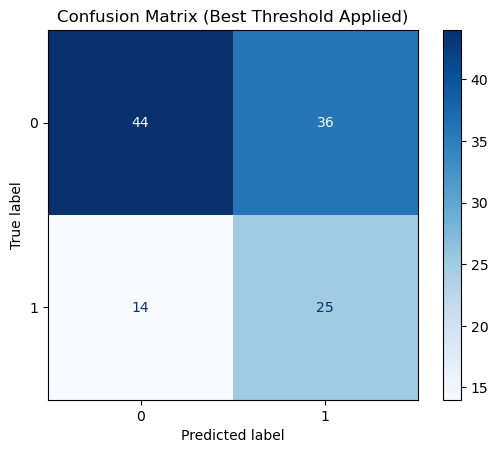

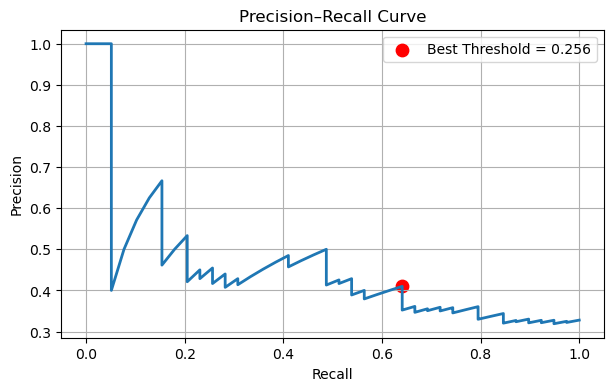

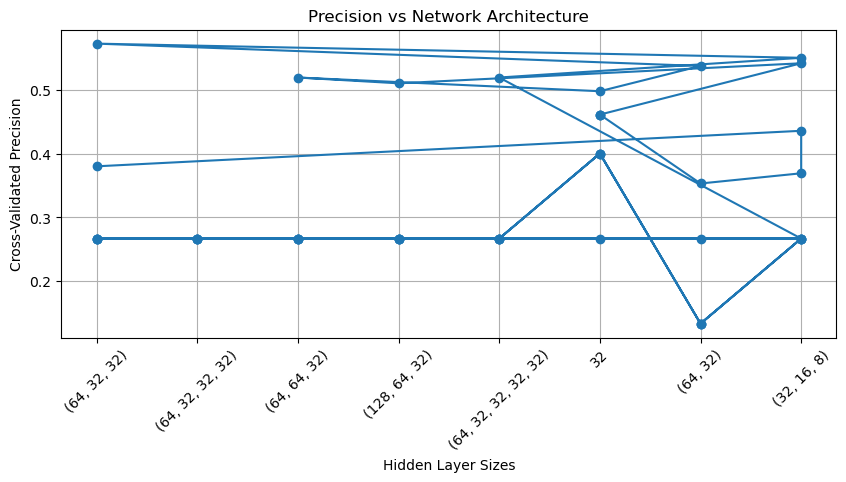

In [11]:
best_model,best_threshold = UMP_predictor_ffnn_model(x_train, y_train, x_val, y_val)

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.metrics import (
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    make_scorer,
    precision_recall_curve
)


def UMP_predictor_knn_model(X_train, y_train, X_val, y_val):
    # Define base KNN model
    model = KNeighborsClassifier()

    # Hyperparameter grid
    param_grid = {
        'n_neighbors': [1, 3, 5, 7, 9, 11,13,15,17,19],
        'weights': ['uniform', 'distance'],
        'p': [1, 2]
    }

    precision_scorer = make_scorer(precision_score, zero_division=0)

    search = HalvingGridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=precision_scorer,
        cv=5,
        factor=3,
        verbose=1
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    print("\nBest Hyperparameters:", search.best_params_)

    # Validation predictions
    y_pred = best_model.predict(X_val)
    final_precision = precision_score(y_val, y_pred, zero_division=0)
    print("Validation Precision:", final_precision)

    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix (Best KNN Model)")
    plt.show()

    # --- Precision vs n_neighbors ---
    results = search.cv_results_
    k_values = results['param_n_neighbors']
    mean_precisions = results['mean_test_score']

    plt.figure(figsize=(7, 4))
    plt.plot(k_values, mean_precisions, marker='o')
    plt.xlabel("n_neighbors (k)")
    plt.ylabel("Cross-Validated Precision")
    plt.title("Precision vs Number of Neighbors (k)")
    plt.grid(True)
    plt.show()

    # --- Precision–Recall Curve + Best Threshold ---
    y_scores = best_model.predict_proba(X_val)[:, 1]

    precision, recall, thresholds = precision_recall_curve(y_val, y_scores)

    # Compute F1-score for each threshold (last precision/recall pair has no threshold)
    f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-12)

    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_p = precision[best_idx]
    best_r = recall[best_idx]

    print(f"Best Threshold (max F1): {best_threshold:.4f}")
    print(f"Precision at best threshold: {best_p:.3f}")
    print(f"Recall at best threshold: {best_r:.3f}")

    # Plot PR curve + best threshold marker
    plt.figure(figsize=(7, 4))
    plt.plot(recall, precision, linewidth=2, label="PR Curve")
    plt.scatter(best_r, best_p, color="red", s=70, label=f"Best Threshold = {best_threshold:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall Curve (Best KNN Model)")
    plt.legend()
    plt.grid(True)
    plt.show()

    return best_model, best_threshold


n_iterations: 3
n_required_iterations: 4
n_possible_iterations: 3
min_resources_: 20
max_resources_: 473
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 40
n_resources: 20
Fitting 5 folds for each of 40 candidates, totalling 200 fits


c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\model_selection\_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\model_selection\_validation.py", line 942, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\fderi\.conda\e

----------
iter: 1
n_candidates: 14
n_resources: 60
Fitting 5 folds for each of 14 candidates, totalling 70 fits


c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [0.3        0.3        0.3        0.3        0.1        0.1
 0.3        0.3        0.2        0.3        0.2        0.4
 0.2        0.4        0.2        0.4        0.26666667 0.4
 0.25       0.2        0.         0.2        0.         0.2
 0.         0.         0.         0.2        0.         0.
 0.         0.2        0.                nan        nan        nan
 0.                nan        nan        nan 0.05       0.15357143
 0.13571429 0.32666667 0.35666667 0.35       0.29333333 0.31333333
 0.31333333 0.32666667 0.28       0.23       0.34666667 0.22      ]
  warnings.warn(
c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the train scores are non-finite: [1.         1.         1.         1.         0.68333333 1.
 0.67619048 1.         0.45714286 1.         0.4571

----------
iter: 2
n_candidates: 5
n_resources: 180
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best Hyperparameters: {'n_neighbors': 5, 'p': 2, 'weights': 'distance'}
Validation Precision: 0.5


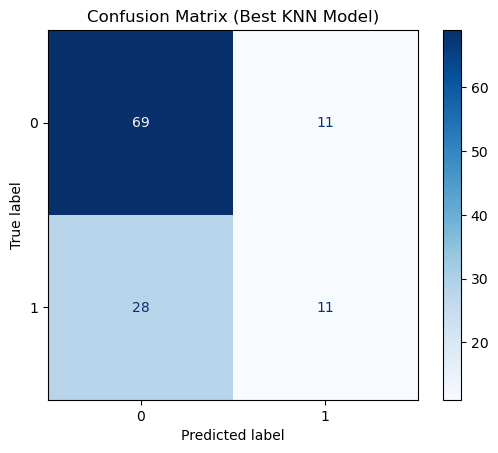

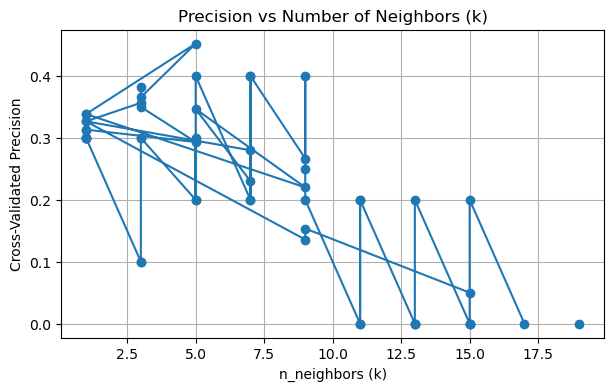

Best Threshold (max F1): 0.1247
Precision at best threshold: 0.419
Recall at best threshold: 0.923


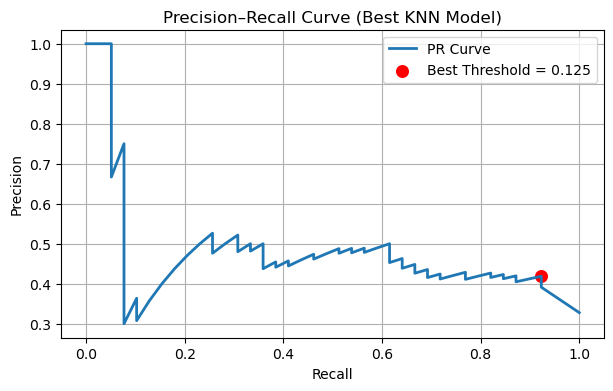

In [13]:
best_model = UMP_predictor_knn_model(x_train, y_train, x_val, y_val)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay,
    make_scorer
)


def UMP_predictor_gbt_model(X_train, y_train, X_val, y_val):

    # ---- Base Gradient Boosted Tree Model ----
    model = GradientBoostingClassifier(random_state=42)

    # ---- Hyperparameter grid ----
    param_grid = {
        'n_estimators': [25,50,75,100,150,],
        'learning_rate': [0.01,0.03,0.04,0.05],
        'max_depth': [2, 3, 4, 5],
        'subsample': [0.7, 0.8,0.9, 1.0],
        'min_samples_split': [2, 5, 7,10],
    }


    scorer = make_scorer(precision_score, zero_division=0)

    search = HalvingGridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=scorer,
        cv=5,
        factor=3,
        verbose=1
    )

    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    weights = np.where(y_train == 1, 1.0, 2.0)
    best_model.fit(X_train, y_train, sample_weight=weights)

    print("\nBest Hyperparameters:", search.best_params_)

    # ---- Predicted probabilities for positive class ----
    y_scores = best_model.predict_proba(X_val)[:, 1]

    # ---- Compute Precision–Recall & Best Threshold ----
    precisions, recalls, thresholds = precision_recall_curve(y_val, y_scores)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

    precisions = precisions[:-1]
    recalls = recalls[:-1]
    f1_scores = f1_scores[:-1]
    mask = recalls >= 0.2
    candidate_precisions = precisions[mask]
    candidate_thresholds = thresholds[mask]

    best_index = np.argmax(candidate_precisions)
    best_threshold = candidate_thresholds[best_index]
    
    print(f"\nBest Threshold (max F1): {best_threshold:.4f}")
    print(f"Precision at best threshold: {candidate_precisions[best_index]:.4f}")
    print(f"Recall at best threshold: {recalls[mask][best_index]:.4f}")
    print(f"F1-score at best threshold: {f1_scores[mask][best_index]:.4f}")

    # ---- Apply threshold ----
    y_pred = (y_scores >= best_threshold).astype(int)

    # ---- Confusion Matrix ----
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix (Best Threshold Applied)")
    plt.show()

    # ---- Precision–Recall Curve ----
    plt.figure(figsize=(7,4))
    plt.plot(recalls, precisions, linewidth=2)
    plt.scatter(recalls[best_index], precisions[best_index],
                color='red', s=80,
                label=f"Best Threshold = {best_threshold:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---- Hyperparameter performance visualization ----
    results = search.cv_results_
    mean_f1 = results['mean_test_score']

    # Create labels based on (n_estimators, learning_rate, max_depth)
    labels = [
        f"{results['param_n_estimators'][i]}, "
        f"{results['param_learning_rate'][i]}, "
        f"{results['param_max_depth'][i]}"
        for i in range(len(mean_f1))
    ]

    plt.figure(figsize=(12,4))
    plt.plot(labels, mean_f1, marker='o')
    plt.xticks(rotation=75)
    plt.xlabel("(n_estimators, learning_rate, max_depth)")
    plt.ylabel("Cross-Validated F1 Score")
    plt.title("Gradient Boosted Tree Hyperparameter Results")
    plt.grid(True)
    plt.show()

    return best_model, best_threshold


n_iterations: 3
n_required_iterations: 6
n_possible_iterations: 3
min_resources_: 20
max_resources_: 473
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 576
n_resources: 20
Fitting 5 folds for each of 576 candidates, totalling 2880 fits
----------
iter: 1
n_candidates: 192
n_resources: 60
Fitting 5 folds for each of 192 candidates, totalling 960 fits
----------
iter: 2
n_candidates: 64
n_resources: 180
Fitting 5 folds for each of 64 candidates, totalling 320 fits

Best Hyperparameters: {'learning_rate': 0.04, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100, 'subsample': 0.9}

Best Threshold (max F1): 0.4547
Precision at best threshold: 0.6923
Recall at best threshold: 0.2308
F1-score at best threshold: 0.3462


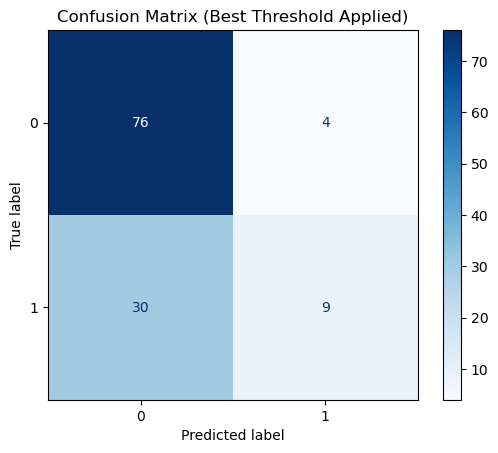

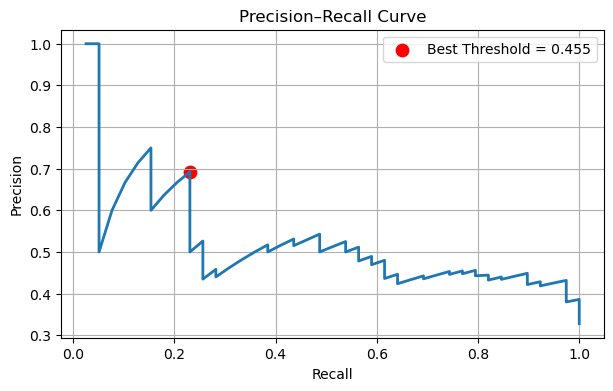

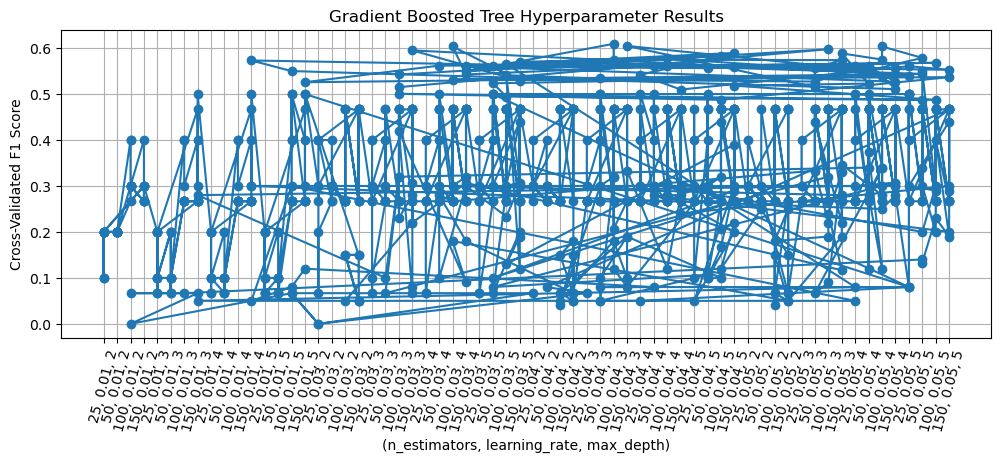

In [19]:
best_model,best_threshold = UMP_predictor_gbt_model(x_train, y_train, x_val, y_val)

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay,
    make_scorer
)

def UMP_predictor_gbt_model(X_train, y_train, X_val, y_val):

    # ---- Base model ----
    base_model = GradientBoostingClassifier(random_state=42)

    # ---- Hyperparameter grid ----
    param_grid = {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05],
        'max_depth': [2, 3, 4],
        'subsample': [0.7, 0.9, 1.0],
        'min_samples_split': [2, 5, 10],
    }

    scorer = make_scorer(precision_score, zero_division=0)

    search = HalvingGridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring=scorer,
        cv=5,
        factor=3,
        verbose=1
    )

    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    # ---- Apply class weights via sample_weight ----
    weights = np.where(y_train == 1, 1.0, 2.0)
    best_model.fit(X_train, y_train, sample_weight=weights)

    print("\nBest Hyperparameters:", search.best_params_)

    # ---- Probability Calibration ----
    calibrated_model = CalibratedClassifierCV(best_model, cv='prefit', method='isotonic')
    calibrated_model.fit(X_train, y_train)

    # ---- Predict calibrated probabilities ----
    y_scores = calibrated_model.predict_proba(X_val)[:, 1]

    # ---- Manually compute FP=0 threshold ----
    thresholds = np.sort(np.unique(y_scores))
    best_thr = 1.0
    best_recall = 0.0

    for t in thresholds:
        y_pred = (y_scores >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

        if fp <= 5:  # STRICT REQUIREMENT
            recall = tp / (tp + fn + 1e-9)
            if recall > best_recall:
                best_recall = recall
                best_thr = t

    print(f"\nSelected Threshold (FP = 0): {best_thr:.4f}")
    print(f"Recall at FP=0: {best_recall:.4f}")

    # ---- Apply chosen threshold ----
    y_pred = (y_scores >= best_thr).astype(int)

    # ---- Confusion matrix ----
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix (Threshold={best_thr:.3f}, FP=0 target)")
    plt.show()

    # ---- PR Curve ----
    precisions, recalls, pr_thresholds = precision_recall_curve(y_val, y_scores)

    plt.figure(figsize=(7,4))
    plt.plot(recalls, precisions, linewidth=2)
    plt.scatter(best_recall, precisions[np.argmax(recalls >= best_recall)],
                color='red', s=80,
                label=f"FP = 0 threshold = {best_thr:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Calibrated Precision–Recall Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

    return calibrated_model, best_thr


n_iterations: 3
n_required_iterations: 5
n_possible_iterations: 3
min_resources_: 20
max_resources_: 473
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 162
n_resources: 20
Fitting 5 folds for each of 162 candidates, totalling 810 fits
----------
iter: 1
n_candidates: 54
n_resources: 60
Fitting 5 folds for each of 54 candidates, totalling 270 fits
----------
iter: 2
n_candidates: 18
n_resources: 180
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best Hyperparameters: {'learning_rate': 0.01, 'max_depth': 2, 'min_samples_split': 10, 'n_estimators': 200, 'subsample': 0.7}

Selected Threshold (FP = 0): 0.7500
Recall at FP=0: 0.1538


c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


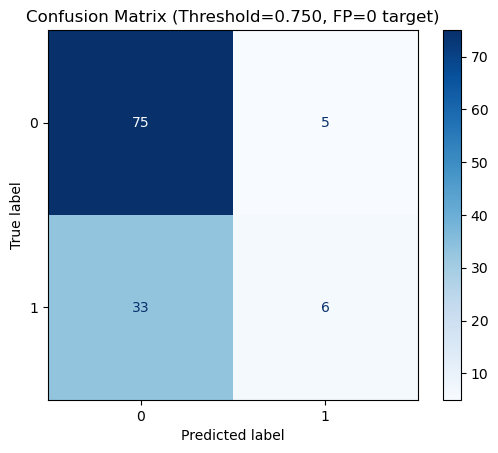

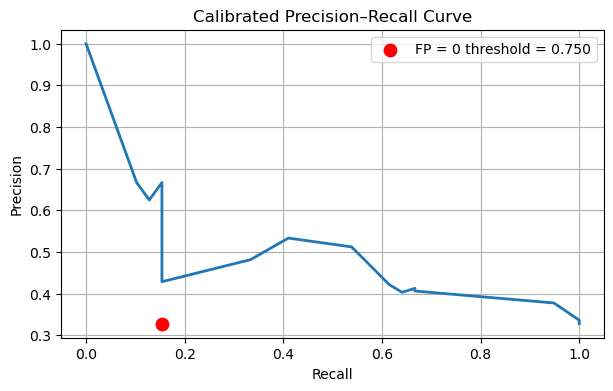

In [17]:
best_model,best_threshold = UMP_predictor_gbt_model(x_train, y_train, x_val, y_val)